<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Florencia Vanella


# Consigna

En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

- Senoidal de frecuencia $f0=k0∗fS/N=k0.Δf$
  
- Potencia normalizada, es decir energía (o varianza) unitaria

  
Se pide:


##### a) Sea k0=
 

##### $N4$
 
##### $N4+0.25$
 
##### $N4+0.5$
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  $Δf$. 

Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

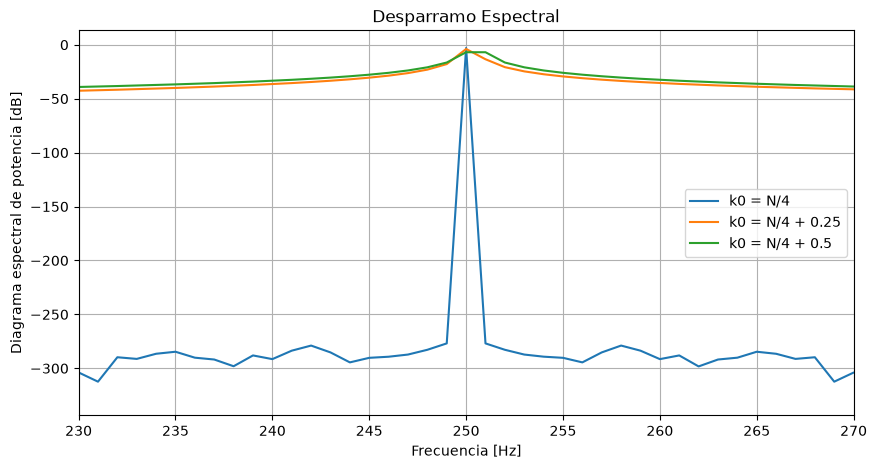

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import math 
from matplotlib.pyplot import subplot
import scipy.stats as stats
from scipy.stats import kstest

# Parámetros generales
N = 1000
Fs = 1000
Ts = 1 / Fs
df = Fs / N  # Resolución espectral (1 Hz)

t = np.arange(N) * Ts
freqs = np.fft.fftfreq(N, Ts) # Vector de frecuencias

k0_1 = N / 4
k0_2 = N / 4 + 0.25
k0_3 = N / 4 + 0.5

# Senoidales
s1 = np.sqrt(2) * np.sin(2 * np.pi * (k0_1 * df) * t)
s2 = np.sqrt(2) * np.sin(2 * np.pi * (k0_2 * df) * t)
s3 = np.sqrt(2) * np.sin(2 * np.pi * (k0_3 * df) * t)

#Cálculo de FFT 
X1 = np.fft.fft(s1)
fft1 = np.abs(X1) / N

X2 = np.fft.fft(s2)
fft2 = np.abs(X2) / N

X3 = np.fft.fft(s3)
fft3 = np.abs(X3) / N


#PSD
psd1_db = 10 * np.log10(fft1**2)

psd2_db = 10 * np.log10(fft2**2)

psd3_db = 10 * np.log10(fft3**2 )


plt.figure(figsize=(10, 5))
plt.plot(freqs[:N//2], psd1_db[:N//2], label="k0 = N/4")
plt.plot(freqs[:N//2], psd2_db[:N//2], label="k0 = N/4 + 0.25")
plt.plot(freqs[:N//2], psd3_db[:N//2], label="k0 = N/4 + 0.5")

plt.title("Desparramo Espectral")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Diagrama espectral de potencia [dB]")
plt.xlim([230, 270])
plt.grid(True)
plt.legend()
plt.show()

##### b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. 
##### En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

In [2]:
# Verificación de Parseval
P_t1 = np.mean(s1**2)
P_f1 = np.sum(fft1**2)

P_t2 = np.mean(s2**2)
P_f2 = np.sum(fft2**2)

P_t3 = np.mean(s3**2)
P_f3 = np.sum(fft3**2)

print(f"Potencia s1 -> Dominio de tiempo: {P_t1:.4f} W | DFT: {P_f1:.4f} W")
print(f"Potencia s2 -> Dominio de tiempo: {P_t2:.4f} W | DFT: {P_f2:.4f} W")
print(f"Potencia s3 -> Dominio de tiempo: {P_t3:.4f} W | DFT: {P_f3:.4f} W")

Potencia s1 -> Dominio de tiempo: 1.0000 W | DFT: 1.0000 W
Potencia s2 -> Dominio de tiempo: 0.9990 W | DFT: 0.9990 W
Potencia s3 -> Dominio de tiempo: 1.0000 W | DFT: 1.0000 W


A primera vista parece raro que dos señales que solo se diferencian por $0.5 Hz$ tengan un espectro tan distinto, pero la razón es cómo la DFT toma las muestras del espectro:
Al recortar la senoidal en $N$ muestras, su espectro real continuo siempre tiene forma de función $sinc$.
La DFT no grafica la curva continua, sino que "captura" en puntos discretos cada $1Hz$ ($249, 250, 251Hz$, etc.).
En $s_1$ ($250Hz$), la frecuencia cae justo en un punto de la DFT y casualmente todas las demás fotos caen exacto en los ceros de la $sinc$. Por eso se ve como un unico pico y perfecto. 
En $s_3$ ($250.5Hz$), la frecuencia cae en el medio de dos puntos. Al "capturar" fuera de los ceros, quedan al descubierto las ondas laterales y la energía se desparrama a los vecinos.

##### c) Repetir el experimento mediante la técnica de zero padding. 
##### Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf de forma ficticia. Probar agregando un vector de $9*N$ ceros al final. Discuta los resultados obtenidos.

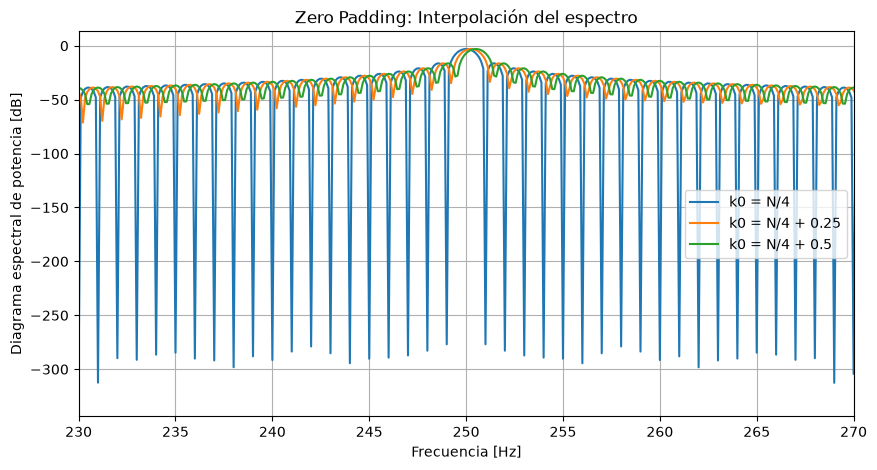

In [3]:

# Zero Padding
N_zp = 9 * N
freqs_zp = np.fft.fftfreq(N_zp, Ts)

# FFT con zero-padding 

X1_zp = np.fft.fft(s1,N_zp)
fft1_zp = np.abs(X1_zp) / N
psd1_zp_db = 10 * np.log10(fft1_zp**2 )

X2_zp = np.fft.fft(s2, N_zp)
fft2_zp = np.abs(X2_zp) / N
psd2_zp_db = 10 * np.log10(fft2_zp**2 )

X3_zp = np.fft.fft(s3,N_zp)
fft3_zp = np.abs(X3_zp) / N
psd3_zp_db = 10 * np.log10(fft3_zp**2)


plt.figure(figsize=(10, 5))
plt.plot(freqs_zp[:N_zp//2], psd1_zp_db[:N_zp//2], label="k0 = N/4")
plt.plot(freqs_zp[:N_zp//2], psd2_zp_db[:N_zp//2], label="k0 = N/4 + 0.25")
plt.plot(freqs_zp[:N_zp//2], psd3_zp_db[:N_zp//2], label="k0 = N/4 + 0.5")

plt.title("Zero Padding: Interpolación del espectro")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Diagrama espectral de potencia [dB]")
plt.xlim([230, 270])
plt.grid(True)
plt.legend()
plt.show()

Sin ceros ($N=1000$): La DFT solo saca 1000 fotos del espectro. 
Esos puntos caen tan separados entre sí haciendo que parezca una línea suave.
Con ceros ($N_{zp}=9000$): Al meter 9000 ceros, obligo a la DFT a sacar 9.000 fotos. Al tomar puntos tan pegados, ahora sí la DFT llega a tocar cada pico y cada cero de esa sinc ondulada, por lo que se ven todas esas "ondas pegadas" dibujadas en el gráfico.
El Zero Padding permite visualizar la curva continua de la ventana con sus lóbulos secundarios, los cuales antes quedaban ocultos entre los puntos de la DFT.